# Artificial intelligence and Machine learning Task _ 02 


In [2]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Step 2: Load the California Housing Dataset
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseValue'] = california.target

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# Step 3: Exploratory Data Analysis & Data Preprocessing
print(df.isnull().sum()) # Check for missing values

# Define features (X) and target (y)
X = df.drop('MedHouseValue', axis=1)
y = df['MedHouseValue']

# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

MedInc           0
HouseAge         0
AveRooms         0
AveBedrms        0
Population       0
AveOccup         0
Latitude         0
Longitude        0
MedHouseValue    0
dtype: int64


In [5]:
# Step 4: Train Multiple Regression Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    # Train model on scaled data
    model.fit(X_train_scaled, y_train)
    
    # Predict on test data
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2
    })

In [6]:
# Step 5: Model Performance Comparison Table
performance_df = pd.DataFrame(results)
performance_df = performance_df.sort_values(by="R2 Score", ascending=False).reset_index(drop=True)
print("--- Model Performance Comparison ---")
display(performance_df)

--- Model Performance Comparison ---


,Model,MSE,RMSE,MAE,R2 Score
0,Random Forest,0.255170,0.505143,0.327425,0.805275
1,Gradient Boosting,0.293999,0.542217,0.371650,0.775643
2,Decision Tree,0.493969,0.702829,0.453904,0.623042
3,Linear Regression,0.555892,0.745581,0.533200,0.575788


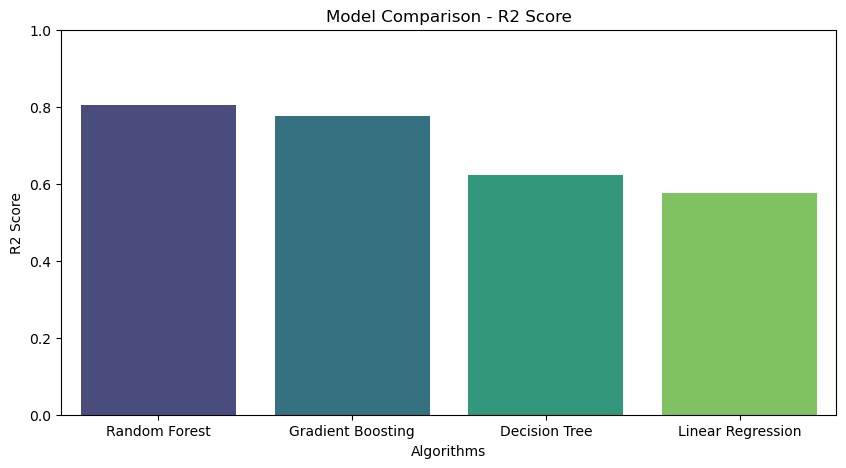

In [7]:
# Step 6: Visualize Model Performance Comparison
plt.figure(figsize=(10, 5))
sns.barplot(x="Model", y="R2 Score", data=performance_df, palette="viridis")
plt.title("Model Comparison - R2 Score")
plt.ylim(0, 1)
plt.ylabel("R2 Score")
plt.xlabel("Algorithms")
plt.show()

In [9]:
# Step 7: Save the Best-Performing Model using joblib
# Identify best model based on highest R2 Score
best_model_name = performance_df.loc[0, "Model"]
best_model = models[best_model_name]

print(f"The best performing model is: {best_model_name}")

# Save model and scaler
joblib.dump(best_model, 'best_house_price_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and scaler successfully saved!")

The best performing model is: Random Forest
Model and scaler successfully saved!
